In [3]:
import torch
import matplotlib.pyplot as plt

def compute_variance_map(dataloader, image_shape, device='cuda'):
    """
    Computes the variance map for a large dataset iteratively.
    image_shape: e.g., (3, 256, 256) or (1, 256, 256)
    """
    # Initialize accumulators on the GPU/CPU as 64-bit floats to prevent overflow
    sum_x = torch.zeros(image_shape, dtype=torch.float64, device=device)
    sum_x2 = torch.zeros(image_shape, dtype=torch.float64, device=device)
    n_samples = 0

    print("Accumulating statistics...")
    with torch.no_grad(): # No gradients needed for this
        for batch in dataloader:
            # Move batch to device and ensure it's a float

            batch = batch[0].to(device).to(torch.float64)

            # Accumulate sum and sum of squares across the batch dimension (dim=0)
            sum_x += batch.sum(dim=0)
            sum_x2 += (batch ** 2).sum(dim=0)
            n_samples += batch.size(0)

    print(f"Processed {n_samples} images. Computing final map...")

    # Calculate Mean: E[X]
    mean_map = sum_x / n_samples

    # Calculate Mean of Squares: E[X^2]
    mean_sq_map = sum_x2 / n_samples

    # Calculate Variance: E[X^2] - (E[X])^2
    variance_map = mean_sq_map - (mean_map ** 2)

    # Convert back to 32-bit float for standard usage
    return variance_map.to(torch.float32), mean_map.to(torch.float32)

# --- Visualization Step ---
def plot_variance_map(variance_map):
    # If it's a 3-channel (RGB) variance map, average across channels for a single heatmap
    if variance_map.shape[0] == 3:
        variance_map = variance_map.mean(dim=0)
    elif len(variance_map.shape) == 3 and variance_map.shape[0] == 1:
        variance_map = variance_map.squeeze(0)

    # Move to CPU for plotting
    var_map_cpu = variance_map.cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.title("Background Variance Map")
    plt.imshow(var_map_cpu, cmap='jet') # 'jet' or 'inferno' are great for heatmaps
    plt.colorbar(label='Variance')
    plt.axis('off')
    plt.show()

In [19]:
from dataloader import *

# train_image_path = '/shared/anastasio-s2/SI/HCP_selected/{}/train/data.h5'.format('sks_3.0_0.2_25.0_c2_num_signals_diffusion_n')
#
# train_dataset = MRIDataset1_2(train_image_path)
#
# train_dataloader = DataLoader(
#     train_dataset,  # Your dataset
#     batch_size=64,  # Batch size (samples per batch)
#     shuffle=False,  # Whether to shuffle data
#     drop_last=True,  # Drop incomplete batches
#     num_workers=4,  # Number of CPU processes for data reading
#     pin_memory=True,  # Accelerate CPU->GPU copy
#     persistent_workers=True,  # Workers do not restart repeatedly
#     prefetch_factor=8,  # How many batches to prefetch
# )
import webdataset as wds

train_image_path = '/shared/anastasio-s2/SI/HCP_selected/background/train/dataset-{000000..000017}.tar'

train_dataset = (
    wds.WebDataset(train_image_path, shardshuffle=True)
    .shuffle(10000)  # Shuffle the shards and maintain a local buffer of 10000 samples
    .decode("torch")
    .to_tuple("npy")  # Extract the "jpg" and "cls" keys we defined during writing
    .batched(256)  # Batch them together (e.g., batch size 64)
    .with_length(671)
)

train_dataloader = DataLoader(train_dataset, num_workers=4, batch_size=None)

In [26]:
a = iter(train_dataloader)
a_ = next(a)

In [27]:
a_[0].mean()

tensor(0.3248)

In [2]:
variance_map, mean_map = compute_variance_map(train_dataloader, train_dataset[0][0].shape)

NameError: name 'compute_variance_map' is not defined

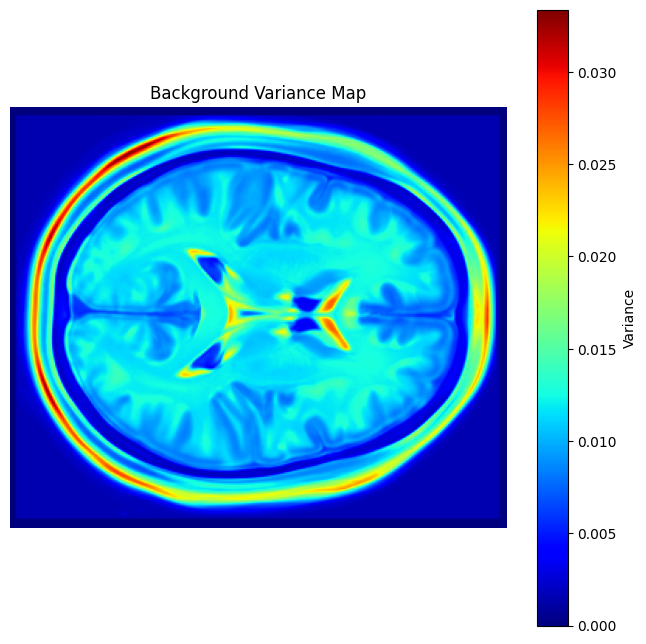

In [11]:
plot_variance_map(variance_map)